In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset, random_split
import torch.nn as nn
import pandas as pd
import math

In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
torch.set_default_device(DEVICE)

Using device: cuda


In [3]:
data = pd.read_csv('ranking_dataset.csv')
data.describe()
X = data.iloc[:, 0:10]
y = data.iloc[:, 10:20]
display(X.describe())
display(y.describe())
display(X.head())
display(y.head())

,val_0,val_1,val_2,val_3,val_4,val_5,val_6,val_7,val_8,val_9
count,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,500.537200,506.623500,501.396300,501.42390,493.817300,495.837500,501.616300,505.314100,500.361700,500.02570
std,290.444477,289.410167,288.372805,289.29438,289.255414,290.777883,288.663129,288.731189,288.747163,290.38134
min,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,248.000000,255.750000,256.000000,251.00000,244.000000,240.000000,250.750000,257.000000,249.000000,248.00000
50%,500.000000,511.000000,500.000000,505.00000,489.000000,496.000000,504.000000,504.000000,501.500000,501.00000
75%,755.000000,757.000000,752.250000,754.25000,745.000000,746.000000,753.250000,757.000000,752.000000,754.00000
max,999.000000,999.000000,999.000000,999.00000,999.000000,999.000000,999.000000,999.000000,999.000000,999.00000


,rank_0,rank_1,rank_2,rank_3,rank_4,rank_5,rank_6,rank_7,rank_8,rank_9
count,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.508600,4.546900,4.49630,4.511000,4.444500,4.443100,4.506400,4.544000,4.498000,4.501200
std,2.876031,2.888639,2.86056,2.866409,2.884086,2.878297,2.857022,2.867523,2.861261,2.882365
min,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,2.00000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
50%,5.000000,5.000000,4.00000,5.000000,4.000000,4.000000,5.000000,5.000000,4.000000,4.000000
75%,7.000000,7.000000,7.00000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000
max,9.000000,9.000000,9.00000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000


,val_0,val_1,val_2,val_3,val_4,val_5,val_6,val_7,val_8,val_9
0,542,67,876,414,26,335,620,924,950,113
1,378,14,210,954,231,572,315,295,567,706
2,749,876,73,111,899,213,541,769,287,219
3,372,880,475,329,733,564,739,376,632,10
4,186,822,577,519,707,123,143,294,693,677


,rank_0,rank_1,rank_2,rank_3,rank_4,rank_5,rank_6,rank_7,rank_8,rank_9
0,5,1,7,4,0,3,6,8,9,2
1,5,0,1,9,2,7,4,3,6,8
2,6,8,0,1,9,2,5,7,4,3
3,2,9,4,1,7,5,8,3,6,0
4,2,9,5,4,8,0,1,3,7,6


In [4]:
class RankingDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X.values, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


dataset = RankingDataset(X, y)
train_dataloader, test_dataloader, valid_dataloader = [
    DataLoader(x, batch_size=32, shuffle=True, generator=torch.Generator(DEVICE))
    for x in random_split(dataset, [0.6, 0.2, 0.2], generator=torch.Generator(DEVICE))
]

In [13]:
# Implement the positional encoding layer
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 5000):
        super().__init__()

        # Create a matrix of shape (max_len, 1) to hold the position indices
        position = torch.arange(max_len).unsqueeze(1)

        # Compute the divisor terms using a geometric progression
        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )

        # Initialize a matrix of zeros for the positional encodings
        pe = torch.zeros(max_len, d_model)
        # Apply sine to even indices and cosine to odd indices
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)[:, :pe[:, 1::2].shape[1]]  # Handle odd d_model case

        # self.pe = pe  # We don't have to add a batch dimension here because it will be broadcasted when added to the input embeddings
        # Register as a buffer so it's saved with the model state but not updated by gradients
        self.register_buffer("pe", pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: Tensor, shape [batch_size, seq_len, d_model]
        """
        # Add the positional encodings to the input embeddings
        return x + getattr(self, "pe")[:x.size(1), :]

In [6]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model: int, nhead: int, hidden_size: int = 128):
        super().__init__()
        self.d_model = d_model
        self.nhead = nhead
        self.hidden_size = hidden_size
        self.W_q = nn.Parameter(torch.randn(nhead, d_model, hidden_size))  # n query weight matrices
        self.W_k = nn.Parameter(torch.randn(nhead, d_model, hidden_size))  # n key weight matrices
        self.W_v = nn.Parameter(torch.randn(nhead, d_model, hidden_size))  # n value weight matrices
        self.W_o = nn.Parameter(torch.randn(nhead * hidden_size, d_model))  # output weight matrix

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x shape: [batch_size, seq_len, d_model]
        # Compute Q, K, V for all heads
        # Add an extra dimension for broadcasting heads, and an extra dimension for batch size respectively
        Q = x.unsqueeze(1) @ self.W_q.unsqueeze(0)  # shape: [batch_size, nhead, seq_len, hidden_size]
        K = x.unsqueeze(1) @ self.W_k.unsqueeze(0)  # shape: [batch_size, nhead, seq_len, hidden_size]
        V = x.unsqueeze(1) @ self.W_v.unsqueeze(0)  # shape: [batch_size, nhead, seq_len, hidden_size]
        attn_scores = Q @ K.transpose(-2, -1) / math.sqrt(self.hidden_size)  # shape: [batch_size, nhead, seq_len, seq_len]
        attn_weights = torch.softmax(attn_scores, dim=-1)  # shape: [batch_size, nhead, seq_len, seq_len]
        attn_output = attn_weights @ V  # shape: [batch_size, nhead, seq_len, hidden_size]
        concatenated = attn_output.transpose(1, 2).reshape(x.size(0), x.size(1), -1)  # shape: [batch_size, seq_len, nhead * hidden_size]
        attn_output = concatenated @ self.W_o  # shape: [batch_size, seq_len, d_model]
        return attn_output

In [17]:
class Model(nn.Module):
    def __init__(self, input_dim, output_dim, seq_len = 10, d_model=128, nhead=4, dim_feedforward=128):
        super(Model, self).__init__()
        # self.normalizer = nn.LayerNorm((seq_len, input_dim))  # Normalize the input across seq len
        self.embedding = nn.Linear(input_dim, d_model)  # Create an embedding layer to project the input to d_model dimensions
        self.positional_encoding = PositionalEncoding(d_model)  # Add positional encoding to the input embeddings
        self.attention = MultiHeadAttention(d_model, nhead, hidden_size=d_model // nhead)
        self.norm1 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.ReLU(),
            nn.Linear(dim_feedforward, d_model)
        )
        self.norm2 = nn.LayerNorm(d_model)
        self.flatten = nn.Flatten() # we want to flatten the output of the attention mechanism to get a single vector for each sequence
        self.mlp = nn.Sequential(
            nn.Linear(d_model * seq_len, dim_feedforward),
            nn.ReLU(),
            nn.Linear(dim_feedforward, dim_feedforward),
            nn.ReLU(),
            nn.Linear(dim_feedforward, output_dim)
        )

    def forward(self, x):
        # x shape: [batch_size, seq_len, input_dim]
        # x = self.normalizer(x)
        x = self.embedding(x)  # shape: [batch_size, seq_len, d_model]
        x = self.positional_encoding(x) # shape: [batch_size, seq_len, d_model]
        x = self.norm1(x + self.attention(x)) # shape: [batch_size, seq_len, d_model]
        x = self.norm2(x + self.ffn(x)) # shape: [batch_size, seq_len, d_model]
        # We now have seq_len embeddings of size d_model for each token in the sequence. We can flatten this to get a single vector of size seq_len * d_model for each sequence, and then pass it through the MLP to get the final output.
        x = self.flatten(x) # shape: [batch_size, seq_len * d_model]
        x = self.mlp(x) # shape: [batch_size, output_dim]
        return x

model = Model(input_dim=1, output_dim=10).to(DEVICE)

In [22]:
def train(model, train_dataloader, valid_dataloader, epochs=10):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = torch.nn.MSELoss()

    losses = []
    valid_losses = []
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for X_batch, y_batch in train_dataloader:
            X_batch = X_batch.unsqueeze(-1).to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)  # MSELoss expects input and target of shape [batch_size, seq_len]
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        losses.append(total_loss / len(train_dataloader))
        print(f"Epoch {epoch+1}/{epochs}, Loss: {losses[-1]:.4f}")

        model.eval()
        with torch.no_grad():
            valid_loss = 0
            for X_batch, y_batch in valid_dataloader:
                X_batch = X_batch.unsqueeze(-1).to(DEVICE)
                y_batch = y_batch.to(DEVICE)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                valid_loss += loss.item()
        valid_losses.append(valid_loss / len(valid_dataloader))
        print(f"Validation Loss: {valid_losses[-1]:.4f}")

    return losses, valid_losses

Epoch 1/100, Loss: 8.3273
Validation Loss: 8.3135
Epoch 2/100, Loss: 8.3155
Validation Loss: 8.2600
Epoch 3/100, Loss: 8.2828
Validation Loss: 8.2371
Epoch 4/100, Loss: 4.1835
Validation Loss: 0.7432
Epoch 5/100, Loss: 0.6777
Validation Loss: 0.7040
Epoch 6/100, Loss: 0.6612
Validation Loss: 0.7109
Epoch 7/100, Loss: 0.6542
Validation Loss: 0.7062
Epoch 8/100, Loss: 0.6687
Validation Loss: 0.6550
Epoch 9/100, Loss: 0.6385
Validation Loss: 0.6472
Epoch 10/100, Loss: 0.6432
Validation Loss: 0.7390
Epoch 11/100, Loss: 2.9242
Validation Loss: 9.1713
Epoch 12/100, Loss: 1.3445
Validation Loss: 0.7169
Epoch 13/100, Loss: 0.6719
Validation Loss: 0.6961
Epoch 14/100, Loss: 0.6676
Validation Loss: 0.6705
Epoch 15/100, Loss: 0.6931
Validation Loss: 0.7235
Epoch 16/100, Loss: 0.6429
Validation Loss: 0.6535
Epoch 17/100, Loss: 0.6229
Validation Loss: 0.6520
Epoch 18/100, Loss: 0.6133
Validation Loss: 0.6445
Epoch 19/100, Loss: 0.6131
Validation Loss: 0.6132
Epoch 20/100, Loss: 0.6014
Validation Lo

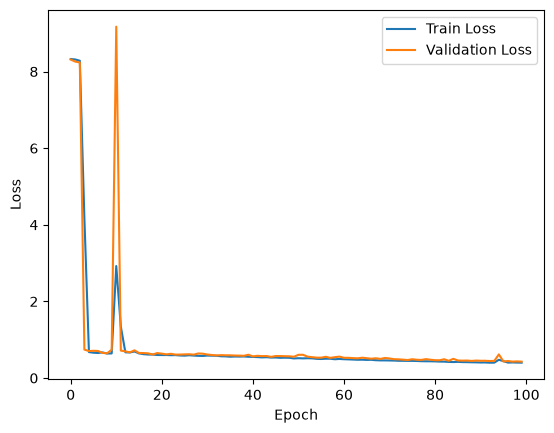

In [23]:
train_losses, valid_losses = train(model, train_dataloader, valid_dataloader, epochs=100)
torch.save(model.state_dict(), 'models/transformer.pth')
plt.plot(train_losses, label='Train Loss')
plt.plot(valid_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [24]:
# Test the model on the test set
model.eval()
test_loss = 0
criterion = torch.nn.MSELoss()
with torch.no_grad():
    for X_batch, y_batch in test_dataloader:
        X_batch = X_batch.unsqueeze(-1).to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        test_loss += loss.item()
test_loss /= len(test_dataloader)
print(f"Test Loss: {test_loss:.4f}")

Test Loss: 0.4206


Average accuracy on test set: 78.1750%


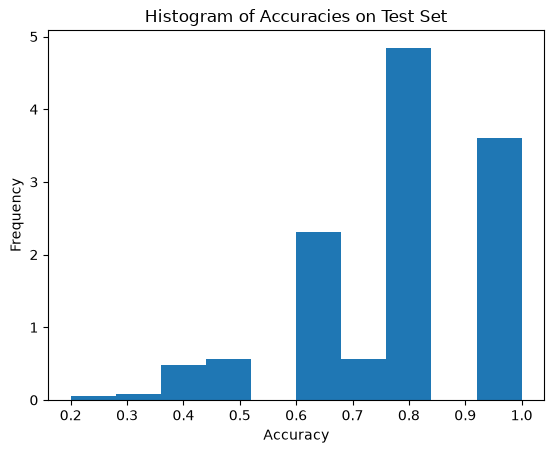

In [27]:
accuracies = []
for X_batch, y_batch in test_dataloader:
    predictions = torch.argsort(torch.argsort(model(X_batch.unsqueeze(-1).to(DEVICE)).cpu(), dim=1), dim=1)
    y_batch = y_batch.cpu()  # The last 10 columns represent the target ranking
    accuracies.extend((predictions == y_batch).float().mean(dim=1).tolist())

# Plot histogram of accuracies:
print(f"Average accuracy on test set: {sum(accuracies) / len(accuracies) * 100:.4f}%")
plt.hist(accuracies, bins=10, density=True)
plt.xlabel('Accuracy')
plt.ylabel('Frequency')
plt.title('Histogram of Accuracies on Test Set')
plt.show()

In [28]:
print(f"Percent of arrays it correctly ranked: {sum([1 for acc in accuracies if acc == 1]) / len(accuracies) * 100:.2f}%")

Percent of arrays it correctly ranked: 28.85%


In [29]:
# Let's see the model's predictions on some test data
sample_input = torch.tensor([23, 25, 12, 5, 17, 9, 30, 1, 8, 15], dtype=torch.float32).to(DEVICE)

with torch.no_grad():
    predicted_ranking = model(sample_input.unsqueeze(0).unsqueeze(-1).to(DEVICE)).squeeze(0).cpu().numpy()

y_true = torch.argsort(torch.argsort(sample_input)).cpu().numpy()  # The true ranking of the input array

print(f"Input:                             {sample_input}")
print(f"Predicted Ranking:                 {predicted_ranking}")
print(f"True Ranking:                      {y_true}")
print(f"Predicted (argsorted):             {np.argsort(np.argsort(predicted_ranking))}")
print(f"True order:                        {sample_input[np.argsort(y_true)]}")
print(f"Input sorted by predicted ranking: {sample_input[np.argsort(predicted_ranking)]}")
print(f"Accuracy:                          {np.mean(np.argsort(np.argsort(predicted_ranking)) == y_true):.4f}")

Input:                             tensor([23., 25., 12.,  5., 17.,  9., 30.,  1.,  8., 15.], device='cuda:0')
Predicted Ranking:                 [6.7679725 7.606408  3.953064  1.3347497 5.6381407 2.6691074 8.325065
 0.0671427 2.2135742 4.874823 ]
True Ranking:                      [7 8 4 1 6 3 9 0 2 5]
Predicted (argsorted):             [7 8 4 1 6 3 9 0 2 5]
True order:                        tensor([ 1.,  5.,  8.,  9., 12., 15., 17., 23., 25., 30.], device='cuda:0')
Input sorted by predicted ranking: tensor([ 1.,  5.,  8.,  9., 12., 15., 17., 23., 25., 30.], device='cuda:0')
Accuracy:                          1.0000
